A notebook for developing reading and parsing of AUPE filter data.

The pipeline is for each Img object to have a method for reading and loading and combining the various component level data to give the transmission response for each AUPE channel.

In addition to the setup for aupy, need to run:

 pip install spectral

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg' # note - requires Inkscape to be installed, and to be accessible from the terminal
# on macos, add inkscape to the path with `sudo ln -s /Applications/Inkscape.app/Contents/MacOS/inkscape /usr/local/bin/inkscape`
%matplotlib inline

We're going to load in the relevant files for each filter, and then write the files to a new filter file.

Then, we'll collect all of these into and ENVI sli/hdr file.

In [1]:
from pathlib import Path
import pandas as pd

In [3]:
trans_data_path = Path('.', 'data', 'response_files', 'PANCAM_TM')

In [4]:
trans_data_path.exists()

True

# Loading HRC Bayer Pattern and Lens Transmission

In [5]:
hrc_trans_path = Path(trans_data_path, 'HRC')

In [6]:
hrc_bayer_path = Path(hrc_trans_path, 'measured_data', 'bayer.csv')

In [7]:
hrc_bayer_path.exists()

True

In [8]:
hrc_bayer_data = pd.read_csv(hrc_bayer_path, header=7)

In [9]:
hrc_bayer_data.head()

,Wavelengths,Red,Green,Blue
0,380,0.021140,0.005379,0.008141
1,381,0.021296,0.005669,0.009152
2,382,0.021452,0.005960,0.010163
3,383,0.021608,0.006466,0.011174
4,384,0.021764,0.006972,0.012185


Clip the data to 0 - 1

In [10]:
# clip the Red, green, and blue channels to the range [0, 1]
hrc_bayer_data['Red'] = hrc_bayer_data['Red'].clip(0, 1)
hrc_bayer_data['Green'] = hrc_bayer_data['Green'].clip(0, 1)
hrc_bayer_data['Blue'] = hrc_bayer_data['Blue'].clip(0, 1)

In [11]:
import seaborn as sns

<Axes: xlabel='Wavelengths'>

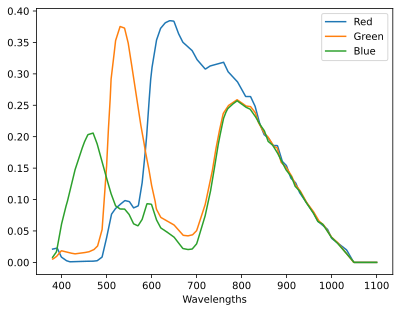

In [12]:
hrc_bayer_data.plot(x='Wavelengths')

And now we load the transmission for the lens glass

In [13]:
hrc_lens_path = Path(hrc_trans_path, 'measured_data','lens.csv')

In [14]:
hrc_lens_data = pd.read_csv(hrc_lens_path, header=7)

In [15]:
hrc_lens_data.head()

,Wavelengths,0,2,5
0,380,2.862519e-20,2.862519e-20,2.862519e-20
1,381,7.781132e-20,7.781132e-20,7.781132e-20
2,382,2.115131e-19,2.115131e-19,2.115131e-19
3,383,5.749522e-19,5.749522e-19,5.749522e-19
4,384,1.562882e-18,1.562882e-18,1.562882e-18


<Axes: xlabel='Wavelengths'>

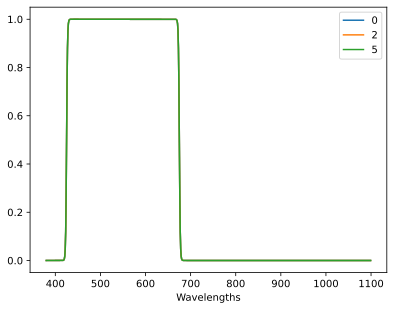

In [16]:
hrc_lens_data.plot(x='Wavelengths')

Note that for the lens data the file includes the expected transmission at 4 different angles of incidence, but over the HRC angular range (~±2.5°) we don't expect much change.

Now we can construct the total transmission for each HRC channel

First we need to interpolate/extapolate all to a common gridding, of 380 - 1100 nm, as set by the Bayer pattern data.

In [17]:
wvls = hrc_bayer_data['Wavelengths'].values

In [18]:
# interpolate and extrapolate the IR cut data
from scipy.interpolate import interp1d

# create a linear interpolation function for the lens data
lens_interp = interp1d(hrc_lens_data['Wavelengths'], hrc_lens_data['0'], bounds_error=False, fill_value='extrapolate')

# apply the linear interpolation function to the wavelengths
lens_interp_data = lens_interp(wvls)

In [19]:
hrc_red_trans = hrc_bayer_data['Red'] * lens_interp_data
hrc_red_trans.index = wvls

hrc_green_trans = hrc_bayer_data['Green'] * lens_interp_data
hrc_green_trans.index = wvls

hrc_blue_trans = hrc_bayer_data['Blue'] * lens_interp_data
hrc_blue_trans.index = wvls

We'll normalise each channel

In [20]:
hrc_red_trans = hrc_red_trans / hrc_red_trans.max()
hrc_green_trans = hrc_green_trans / hrc_green_trans.max()
hrc_blue_trans = hrc_blue_trans / hrc_blue_trans.max()

And clip and make all values non-negative

In [21]:
import numpy as np

In [22]:
hrc_red_trans = np.abs(hrc_red_trans.clip(0,1))
hrc_green_trans = np.abs(hrc_green_trans.clip(0,1))
hrc_blue_trans = np.abs(hrc_blue_trans.clip(0,1))

We'll compute the cwl and fwhm for each channel from the data.

In [23]:
import numpy as np

In [24]:
# get CWl and FWHM values

# RED
enrgy_count = hrc_red_trans * hrc_red_trans.index
norm_enrgy_count = (enrgy_count / enrgy_count.max())

cwl = np.sum((norm_enrgy_count*wvls)) / np.sum((norm_enrgy_count))
red_cwl = np.round(cwl)
half_maxima = 0.5
limits = np.greater(norm_enrgy_count, half_maxima).to_numpy()
wvls_above_hmax = wvls[limits]
red_fwhm = wvls_above_hmax[-1] - wvls_above_hmax[0]

In [25]:
# get CWl and FWHM values

# GREEN
enrgy_count = hrc_green_trans * hrc_green_trans.index
norm_enrgy_count = (enrgy_count / enrgy_count.max())

cwl = np.sum((norm_enrgy_count*wvls)) / np.sum((norm_enrgy_count))
green_cwl = np.round(cwl)
half_maxima = 0.5
limits = np.greater(norm_enrgy_count, half_maxima).to_numpy()
wvls_above_hmax = wvls[limits]
green_fwhm = wvls_above_hmax[-1] - wvls_above_hmax[0]

In [26]:
# get CWl and FWHM values

# BLUE
enrgy_count = hrc_blue_trans * hrc_blue_trans.index
norm_enrgy_count = (enrgy_count / enrgy_count.max())

cwl = np.sum((norm_enrgy_count*wvls)) / np.sum((norm_enrgy_count))
blue_cwl = np.round(cwl)
half_maxima = 0.5
limits = np.greater(norm_enrgy_count, half_maxima).to_numpy()
wvls_above_hmax = wvls[limits]
blue_fwhm = wvls_above_hmax[-1] - wvls_above_hmax[0]

In [73]:
# print the hrc red cwl, green cwl, blue cwl
print(f'HRC Red: {red_cwl} nm, Green: {green_cwl} nm, Blue: {blue_cwl} nm')

HRC Red: 617.0 nm, Green: 557.0 nm, Blue: 522.0 nm


In [75]:
# print the hrc fwhm
print(f'HRC FWHMs: Red: {red_fwhm}, Green: {green_fwhm}, Blue: {blue_fwhm}')

HRC FWHMs: Red: 84, Green: 83, Blue: 178


Now we add the cwl and fwhm information as part of the metadata, and we'll prepare the metadata for export.

Now we'll write each of these to a simple csv file

We'll use the labelling convention given in the aupe_info.csv file

In [27]:
band_names = ['HRCR', 'HRCG', 'HRCB']

In [28]:
hrc_red_trans.name = band_names[0]
hrc_green_trans.name = band_names[1]
hrc_blue_trans.name = band_names[2]

In [29]:
# add the index name as wavelength
hrc_red_trans.index.name = 'Wavelengths'
hrc_green_trans.index.name = 'Wavelengths'
hrc_blue_trans.index.name = 'Wavelengths'

<Axes: xlabel='Wavelengths'>

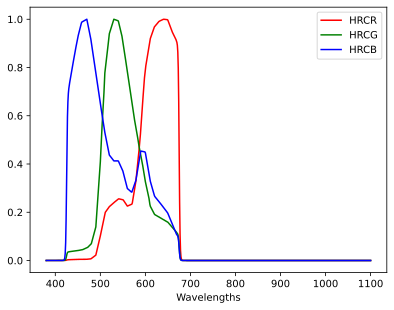

In [30]:
hrc_red_trans.plot(x='Wavelengths', color='red', legend=True)
hrc_green_trans.plot(x='Wavelengths', color='green', legend=True)
hrc_blue_trans.plot(x='Wavelengths', color='blue', legend=True)

In [31]:
hrc_red_trans.to_csv(Path(hrc_trans_path,'HRCR.csv'))
hrc_green_trans.to_csv(Path(hrc_trans_path,'HRCG.csv'))
hrc_blue_trans.to_csv(Path(hrc_trans_path,'HRCB.csv'))

In [32]:
import spectral.io.envi as envi

We need to prepare a header dictionary for to construct the envi.SpectralLibrary object.

This has the structure of:
```header = {
    'wavelength': CONFIG.wvls, # np.ndarray of len n_bands,
    'fwhm': lib_df.fwhm, # typically this information is poorly supplied, so let's estimate with 5 nm for high-resolution spectral library data.
    'spectra names': matcol.main_df['Data ID'], # use the data ids of the material collection
    'wavelength units': 'nm' # the wavelength units used here.
}

For each band, we need to estimate the cwl and fwhm

In [33]:
header = {
    'wavelength': wvls, # np.ndarray of len n_bands,
    'fwhm': np.empty(len(wvls)).fill(3.0), # typically this information is poorly supplied, so let's estimate with 3 nm for high-resolution spectral library data.
    'spectra names': band_names, # use the data ids of the material collection
    'wavelength units': 'nm' # the wavelength units used here.
}

In [34]:
spectra = np.array(
    [hrc_red_trans.to_numpy(),
        hrc_green_trans.to_numpy(),
        hrc_blue_trans.to_numpy()]
)

In [35]:
spectra.shape

(3, 721)

In [36]:
hrc_envi_sli = envi.SpectralLibrary(data=spectra, header=header)

In [37]:
hrc_envi_sli.save(str(Path(hrc_trans_path,'HRC').resolve()))

# LWAC and RWAC Transmission Profiles

Now we need to do the same as above for the LWAC and RWAC. This needs to be a little bit slicker, as there are lots of filters to process.

Lets stash the HRC wvls we were working with as our base for this data also.

In [38]:
wvls

array([ 380,  381,  382,  383,  384,  385,  386,  387,  388,  389,  390,
        391,  392,  393,  394,  395,  396,  397,  398,  399,  400,  401,
        402,  403,  404,  405,  406,  407,  408,  409,  410,  411,  412,
        413,  414,  415,  416,  417,  418,  419,  420,  421,  422,  423,
        424,  425,  426,  427,  428,  429,  430,  431,  432,  433,  434,
        435,  436,  437,  438,  439,  440,  441,  442,  443,  444,  445,
        446,  447,  448,  449,  450,  451,  452,  453,  454,  455,  456,
        457,  458,  459,  460,  461,  462,  463,  464,  465,  466,  467,
        468,  469,  470,  471,  472,  473,  474,  475,  476,  477,  478,
        479,  480,  481,  482,  483,  484,  485,  486,  487,  488,  489,
        490,  491,  492,  493,  494,  495,  496,  497,  498,  499,  500,
        501,  502,  503,  504,  505,  506,  507,  508,  509,  510,  511,
        512,  513,  514,  515,  516,  517,  518,  519,  520,  521,  522,
        523,  524,  525,  526,  527,  528,  529,  5

First lets load the qe, then the lens, and then finally each filter.

In [39]:
geol_trans_path = Path(trans_data_path, 'GEOL')
rgb_trans_path = Path(trans_data_path, 'RGB')

In [42]:
qe_data = pd.read_csv(Path(geol_trans_path, 'measured_data', 'qe.csv'), header=7)

In [43]:
qe_data.head()

,Wavelengths,QE
0,380,-0.017871
1,381,-0.013499
2,382,-0.009128
3,383,-0.004756
4,384,-0.000385


<Axes: xlabel='Wavelengths'>

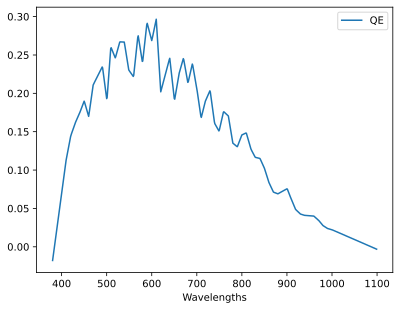

In [44]:
qe_data.plot(x='Wavelengths')

Now the lens data

In [45]:
lens_data = pd.read_csv(Path(geol_trans_path, 'measured_data', 'lens.csv'), header=7)

In [46]:
lens_data.head()

,Wavelengths,0,9.87,19.19,26.44
0,400,0.9134,0.9134,0.9134,0.9075
1,420,0.9373,0.9433,0.9478,0.9463
2,440,0.9627,0.9672,0.9672,0.9597
3,460,0.9761,0.9746,0.9716,0.9612
4,480,0.9657,0.9627,0.9597,0.9507


<Axes: xlabel='Wavelengths'>

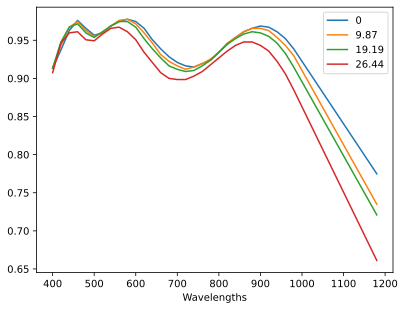

In [47]:
lens_data.plot(x='Wavelengths')

Now lets interpoalte/extrapolate these to the wvls range.

In [48]:

# create a linear interpolation function for the QE data
qe_interp = interp1d(qe_data['Wavelengths'], qe_data['QE'], bounds_error=False, fill_value='extrapolate')
# create a linear interpolation function for the lens data
lens_interp = interp1d(lens_data['Wavelengths'], lens_data['0'], bounds_error=False, fill_value='extrapolate')

# apply the linear interpolation function to the wavelengths
qe_interp_data = qe_interp(wvls)
lens_interp_data = lens_interp(wvls)

## Loading the transmission files

In [49]:
geol_bands = ['G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11', 'G12']
rgb_bands = ['R1R', 'R2G', 'R3B']

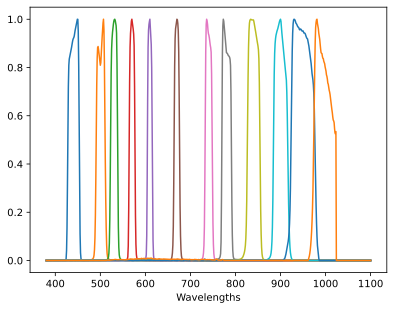

In [53]:
geol_band_data = {}
for band in geol_bands:
    data = pd.read_csv(Path(geol_trans_path,'measured_data', f'{band}.csv'), header=7)
    trans = np.abs(data['0'].clip(0, 1))
    # interp to the wvls
    trans_interp = interp1d(data['Wavelengths'], trans, bounds_error=False, fill_value=0)
    trans_interp_data = trans_interp(wvls)
    # scale by the lens and QE data
    trans_data = trans_interp_data * lens_interp_data * qe_interp_data
    # normalize
    trans_data = trans_data / np.nanmax(trans_data)
    # clip to [0, 1]
    trans_data = np.abs(trans_data.clip(0,1))
    geol_band_data[band] = trans_data

    # write to csv by packaging into a series
    geol_band_s = pd.Series(trans_data, index=wvls)
    geol_band_s.name = band
    geol_band_s.index.name = 'Wavelengths'
    geol_band_s.to_csv(Path(geol_trans_path,f'{band}.csv'))

    geol_band_s.plot(x='Wavelengths')

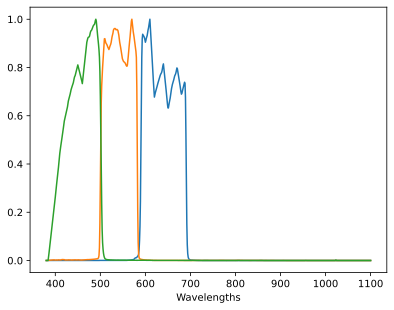

In [54]:
rgb_band_data = {}
for band in rgb_bands:
    data = pd.read_csv(Path(rgb_trans_path,'measured_data', f'{band}.csv'), header=7)
    trans = np.abs(data['0'].clip(0, 1))
    # interp to the wvls
    trans_interp = interp1d(data['Wavelengths'], trans, bounds_error=False, fill_value=0)
    trans_interp_data = trans_interp(wvls)
    # scale by the lens and QE data
    trans_data = trans_interp_data * lens_interp_data * qe_interp_data
    # normalize
    trans_data = trans_data / np.nanmax(trans_data)
    # clip to [0, 1]
    trans_data = np.abs(trans_data.clip(0,1))
    rgb_band_data[band] = trans_data    

    # write to csv by packaging into a series
    rgb_band_s = pd.Series(trans_data, index=wvls)
    rgb_band_s.name = band
    rgb_band_s.index.name = 'Wavelengths'

    rgb_band_s.to_csv(Path(rgb_trans_path,f'{band}.csv'))

    rgb_band_s.plot(x='Wavelengths')

Now to export these into ENVI files

Computing the CWL and FWHM

In [55]:
geol_cwls = {}
geol_fwhms = {}
for band in geol_bands:
    enrgy_count = geol_band_data[band] * wvls
    norm_enrgy_count = (enrgy_count / enrgy_count.max())

    cwl = np.sum((norm_enrgy_count*wvls)) / np.sum((norm_enrgy_count))
    cwl = np.round(cwl)
    half_maxima = 0.5
    limits = np.greater(norm_enrgy_count, half_maxima)
    wvls_above_hmax = wvls[limits]
    fwhm = wvls_above_hmax[-1] - wvls_above_hmax[0]
    geol_cwls[band] = cwl
    geol_fwhms[band] = fwhm

In [56]:
geol_cwls

{'G01': np.float64(441.0),
 'G02': np.float64(501.0),
 'G03': np.float64(531.0),
 'G04': np.float64(570.0),
 'G05': np.float64(610.0),
 'G06': np.float64(670.0),
 'G07': np.float64(740.0),
 'G08': np.float64(779.0),
 'G09': np.float64(839.0),
 'G10': np.float64(900.0),
 'G11': np.float64(949.0),
 'G12': np.float64(989.0)}

In [57]:
geol_fwhms

{'G01': np.int64(25),
 'G02': np.int64(19),
 'G03': np.int64(15),
 'G04': np.int64(11),
 'G05': np.int64(10),
 'G06': np.int64(11),
 'G07': np.int64(15),
 'G08': np.int64(20),
 'G09': np.int64(27),
 'G10': np.int64(30),
 'G11': np.int64(52),
 'G12': np.int64(49)}

In [58]:
rgb_cwls = {}
rgb_fwhms = {}
for band in rgb_bands:
    enrgy_count = rgb_band_data[band] * wvls
    norm_enrgy_count = (enrgy_count / enrgy_count.max())

    cwl = np.sum((norm_enrgy_count*wvls)) / np.sum((norm_enrgy_count))
    cwl = np.round(cwl)
    half_maxima = 0.5
    limits = np.greater(norm_enrgy_count, half_maxima)
    wvls_above_hmax = wvls[limits]
    fwhm = wvls_above_hmax[-1] - wvls_above_hmax[0]
    rgb_cwls[band] = cwl
    rgb_fwhms[band] = fwhm

In [59]:
rgb_cwls

{'R1R': np.float64(639.0), 'R2G': np.float64(543.0), 'R3B': np.float64(459.0)}

In [60]:
rgb_fwhms

{'R1R': np.int64(99), 'R2G': np.int64(79), 'R3B': np.int64(80)}

Make one envi for the wac_geol, one for wac_rgb,

In [61]:
rgb_bands

['R1R', 'R2G', 'R3B']

In [62]:
rgb_header = {
    'wavelength': wvls, # np.ndarray of len n_bands,
    'fwhm': np.empty(len(wvls)).fill(3.0), # typically this information is poorly supplied, so let's estimate with 3 nm for high-resolution spectral library data.
    'spectra names': rgb_bands, # use the data ids of the material collection
    'wavelength units': 'nm' # the wavelength units used here.
}

In [63]:
rgb_spectra = np.array(
        [rgb_band_data[band] for band in rgb_bands]
)

In [64]:
rgb_spectra.shape

(3, 721)

In [65]:
rgb_envi_sli = envi.SpectralLibrary(data=rgb_spectra, header=rgb_header)

In [66]:
rgb_envi_sli.save(str(Path(rgb_trans_path,'RGB').resolve()))

GEOL

In [67]:
geol_bands

['G01',
 'G02',
 'G03',
 'G04',
 'G05',
 'G06',
 'G07',
 'G08',
 'G09',
 'G10',
 'G11',
 'G12']

In [68]:
geol_header = {
    'wavelength': wvls, # np.ndarray of len n_bands,
    'fwhm': np.empty(len(wvls)).fill(3.0), # typically this information is poorly supplied, so let's estimate with 3 nm for high-resolution spectral library data.
    'spectra names': geol_bands, # use the data ids of the material collection
    'wavelength units': 'nm' # the wavelength units used here.
}

In [69]:
geol_spectra = np.array(
        [geol_band_data[band] for band in geol_bands]
)

In [70]:
geol_spectra.shape

(12, 721)

In [71]:
geol_envi_sli = envi.SpectralLibrary(data=geol_spectra, header=geol_header)

In [72]:
geol_envi_sli.save(str(Path(geol_trans_path,'GEOL').resolve()))